In [1]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import sys
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


In [2]:
# Cell 2: Load Processed Data
df = pd.read_csv('../data/processed/diabetes_ml_ready.csv')

print("=" * 50)
print("LOADED ML-READY DATASET")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- Columns ---")
print(df.columns.tolist())

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Target Variable Distribution ---")
if 'Outcome' in df.columns:
    print(df['Outcome'].value_counts())
    print(f"\nClass Balance:")
    print(df['Outcome'].value_counts(normalize=True) * 100)


LOADED ML-READY DATASET
Shape: (768, 16)
Rows: 768, Columns: 16

--- Columns ---
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'Risk_Score', 'Age_BMI', 'Glucose_BMI', 'BMI_Category_Encoded', 'Glucose_Category_Encoded', 'BP_Category_Encoded', 'Age_Group_Encoded']

--- First 5 Rows ---
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0  125.000  33.6   
1            1     85.0           66.0           29.0  125.000  26.6   
2            8    183.0           64.0           29.0  125.000  23.3   
3            1     89.0           66.0           23.0  112.875  28.1   
4            0    137.0           40.0           35.0  135.875  43.1   

   DiabetesPedigreeFunction  Age  Outcome  Risk_Score  Age_BMI  Glucose_BMI  \
0                     0.627   50        1           4   1680.0       4972.8   
1                     0.351   31        0    

In [3]:
# Cell 3: Prepare Data for Training
print("=" * 50)
print("PREPARING DATA FOR TRAINING")
print("=" * 50)

# Separate features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

print(f"\nFeatures: {X.columns.tolist()}")

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

print(f"\nTrain target distribution:")
print(y_train.value_counts())
print(f"\nTest target distribution:")
print(y_test.value_counts())


PREPARING DATA FOR TRAINING

Features shape: (768, 15)
Target shape: (768,)

Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Risk_Score', 'Age_BMI', 'Glucose_BMI', 'BMI_Category_Encoded', 'Glucose_Category_Encoded', 'BP_Category_Encoded', 'Age_Group_Encoded']

Train set: (614, 15)
Test set: (154, 15)

Train target distribution:
Outcome
0    400
1    214
Name: count, dtype: int64

Test target distribution:
Outcome
0    100
1     54
Name: count, dtype: int64


In [4]:
# Cell 4: Feature Scaling
print("=" * 50)
print("FEATURE SCALING")
print("=" * 50)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("✅ Features scaled using StandardScaler")
print(f"\nScaled train set shape: {X_train_scaled.shape}")
print(f"Scaled test set shape: {X_test_scaled.shape}")

print("\n--- Sample scaled values (first row) ---")
print(X_train_scaled.head(1))


FEATURE SCALING
✅ Features scaled using StandardScaler

Scaled train set shape: (614, 15)
Scaled test set shape: (154, 15)

--- Sample scaled values (first row) ---
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0    -0.851355 -1.056427       -0.82674      -1.910489 -1.475845 -0.784098   

   DiabetesPedigreeFunction       Age  Risk_Score   Age_BMI  Glucose_BMI  \
0                  0.400579 -0.792169   -1.409498 -0.980552    -1.076629   

   BMI_Category_Encoded  Glucose_Category_Encoded  BP_Category_Encoded  \
0              1.466924                  0.024495                  0.0   

   Age_Group_Encoded  
0           0.933425  


In [5]:
# Cell 5: Train Multiple Models
print("=" * 50)
print("TRAINING MULTIPLE MODELS")
print("=" * 50)

# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    
    results[name] = {
        'model': model,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred_test
    }
    
    print(f"✅ Train Accuracy: {train_accuracy:.4f}")
    print(f"✅ Test Accuracy: {test_accuracy:.4f}")
    print(f"✅ Precision: {precision:.4f}")
    print(f"✅ Recall: {recall:.4f}")
    print(f"✅ F1 Score: {f1:.4f}")
    print(f"✅ Cross-Val Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

print("\n" + "="*50)
print("✅ All models trained successfully!")


TRAINING MULTIPLE MODELS

Training: Logistic Regression
✅ Train Accuracy: 0.7866
✅ Test Accuracy: 0.7143
✅ Precision: 0.6000
✅ Recall: 0.5556
✅ F1 Score: 0.5769
✅ Cross-Val Score: 0.7752 (+/- 0.0109)

Training: Decision Tree
✅ Train Accuracy: 0.8339
✅ Test Accuracy: 0.7078
✅ Precision: 0.6154
✅ Recall: 0.4444
✅ F1 Score: 0.5161
✅ Cross-Val Score: 0.7264 (+/- 0.0152)

Training: Random Forest
✅ Train Accuracy: 0.9967
✅ Test Accuracy: 0.7532
✅ Precision: 0.6600
✅ Recall: 0.6111
✅ F1 Score: 0.6346
✅ Cross-Val Score: 0.7655 (+/- 0.0314)

✅ All models trained successfully!


MODEL PERFORMANCE COMPARISON

               Model  Train Accuracy  Test Accuracy  Precision   Recall  F1 Score  CV Score
Logistic Regression        0.786645       0.714286   0.600000 0.555556  0.576923  0.775250
      Decision Tree        0.833876       0.707792   0.615385 0.444444  0.516129  0.726429
      Random Forest        0.996743       0.753247   0.660000 0.611111  0.634615  0.765480


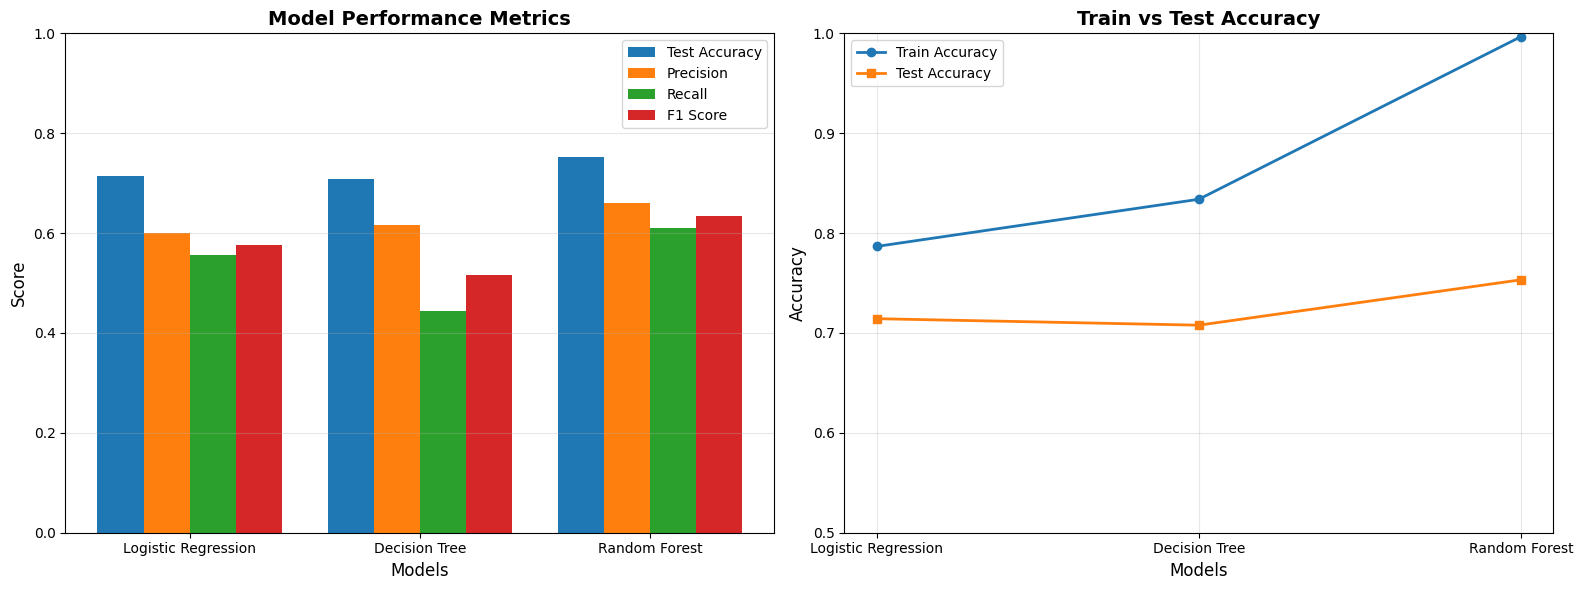


✅ Model comparison visualization saved!

🏆 Best Model: Random Forest
   Test Accuracy: 0.7532


In [6]:
# Cell 6: Model Comparison
print("=" * 50)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 50)

# Create comparison DataFrame
comparison_data = []
for name, result in results.items():
    comparison_data.append({
        'Model': name,
        'Train Accuracy': result['train_accuracy'],
        'Test Accuracy': result['test_accuracy'],
        'Precision': result['precision'],
        'Recall': result['recall'],
        'F1 Score': result['f1_score'],
        'CV Score': result['cv_mean']
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
metrics = ['Test Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(comparison_df))
width = 0.2

for i, metric in enumerate(metrics):
    axes[0].bar(x + i*width, comparison_df[metric], width, label=metric)

axes[0].set_xlabel('Models', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(comparison_df['Model'])
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Train vs Test Accuracy
axes[1].plot(comparison_df['Model'], comparison_df['Train Accuracy'], 
             marker='o', label='Train Accuracy', linewidth=2)
axes[1].plot(comparison_df['Model'], comparison_df['Test Accuracy'], 
             marker='s', label='Test Accuracy', linewidth=2)
axes[1].set_xlabel('Models', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Train vs Test Accuracy', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0.5, 1])

plt.tight_layout()
plt.savefig('../results/plots/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Model comparison visualization saved!")

# Find best model
best_model_name = comparison_df.loc[comparison_df['Test Accuracy'].idxmax(), 'Model']
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Test Accuracy: {comparison_df.loc[comparison_df['Test Accuracy'].idxmax(), 'Test Accuracy']:.4f}")


CONFUSION MATRIX - Random Forest


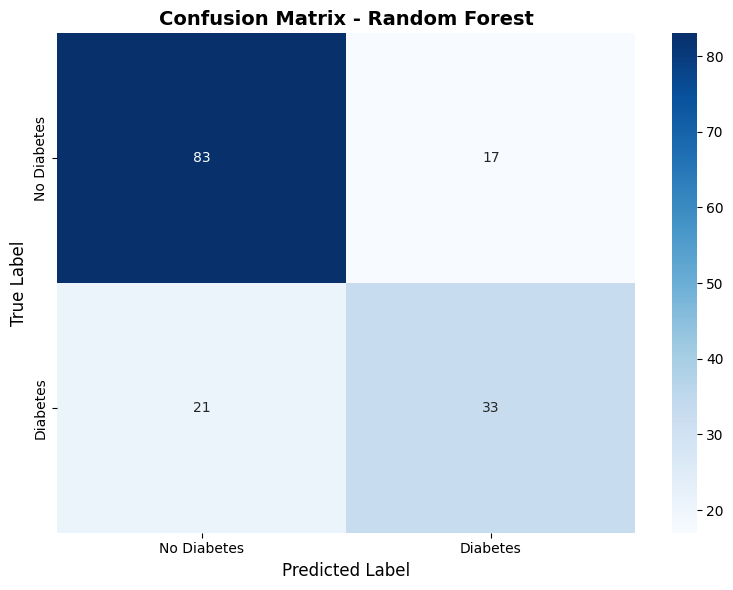


--- Confusion Matrix ---
[[83 17]
 [21 33]]

True Negatives: 83
False Positives: 17
False Negatives: 21
True Positives: 33

✅ Confusion matrix visualization saved!


In [7]:
# Cell 7: Confusion Matrix for Best Model
print("=" * 50)
print(f"CONFUSION MATRIX - {best_model_name}")
print("=" * 50)

best_result = results[best_model_name]
cm = confusion_matrix(y_test, best_result['y_pred'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('../results/plots/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n--- Confusion Matrix ---")
print(cm)
print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

print("\n✅ Confusion matrix visualization saved!")


In [8]:
# Cell 8: Classification Report
print("=" * 50)
print(f"DETAILED CLASSIFICATION REPORT - {best_model_name}")
print("=" * 50)

print("\n", classification_report(y_test, best_result['y_pred'], 
                                   target_names=['No Diabetes', 'Diabetes']))

# Save classification report
report = classification_report(y_test, best_result['y_pred'], 
                               target_names=['No Diabetes', 'Diabetes'],
                               output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv('../results/classification_report.csv')

print("✅ Classification report saved to results/classification_report.csv")


DETAILED CLASSIFICATION REPORT - Random Forest

               precision    recall  f1-score   support

 No Diabetes       0.80      0.83      0.81       100
    Diabetes       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154

✅ Classification report saved to results/classification_report.csv


FEATURE IMPORTANCE ANALYSIS

--- Top 10 Most Important Features ---
                 feature  importance
             Glucose_BMI    0.179936
                 Glucose    0.148425
                 Age_BMI    0.107109
DiabetesPedigreeFunction    0.082919
                     BMI    0.081056
                     Age    0.067437
              Risk_Score    0.066080
           BloodPressure    0.056644
             Pregnancies    0.051308
           SkinThickness    0.047113


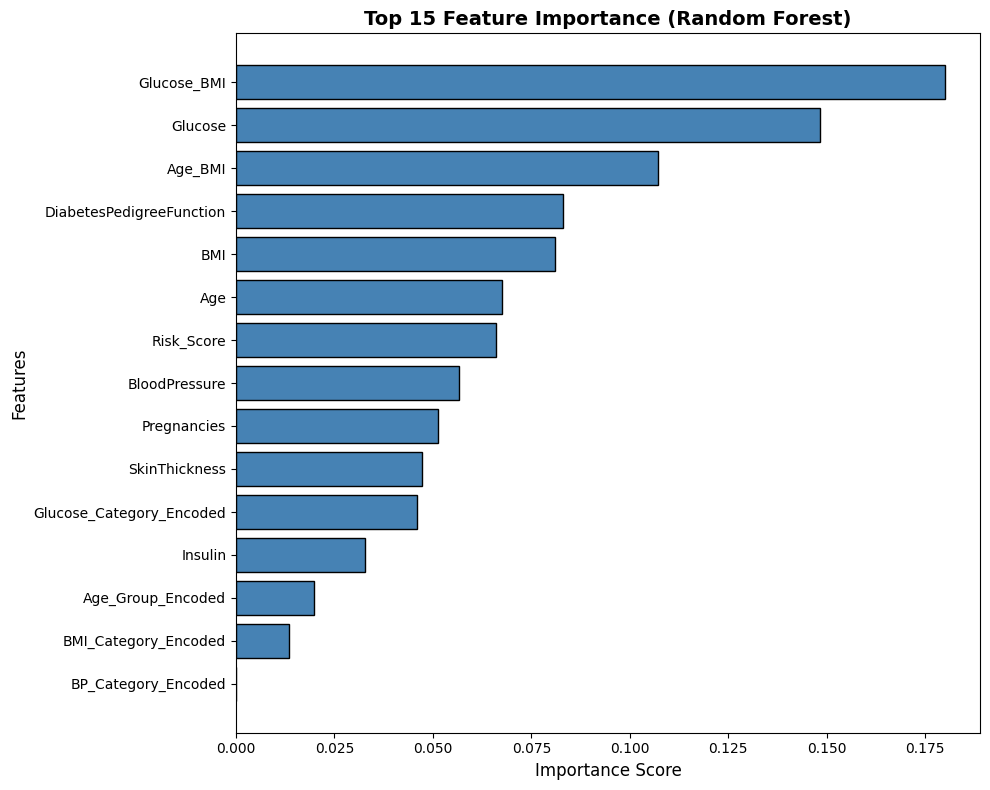


✅ Feature importance visualization saved!
✅ Feature importance saved to results/feature_importance.csv


In [9]:
# Cell 9: Feature Importance (Random Forest)
print("=" * 50)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 50)

# Get Random Forest model
rf_model = results['Random Forest']['model']

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n--- Top 10 Most Important Features ---")
print(feature_importance.head(10).to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['feature'], top_features['importance'], color='steelblue', edgecolor='black')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Top 15 Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../results/plots/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Feature importance visualization saved!")

# Save feature importance
feature_importance.to_csv('../results/feature_importance.csv', index=False)
print("✅ Feature importance saved to results/feature_importance.csv")


ROC CURVE ANALYSIS


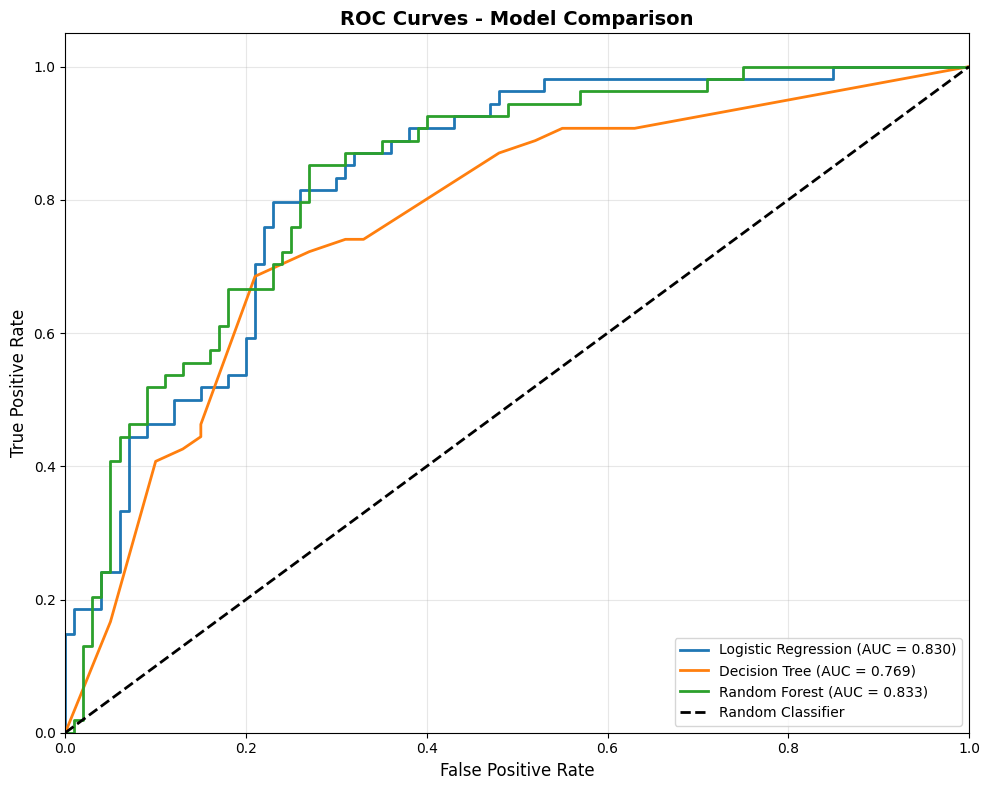

✅ ROC curves visualization saved!


In [10]:
# Cell 10: ROC Curve
print("=" * 50)
print("ROC CURVE ANALYSIS")
print("=" * 50)

plt.figure(figsize=(10, 8))

for name, result in results.items():
    model = result['model']
    
    # Get prediction probabilities
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred_proba = model.decision_function(X_test_scaled)
    
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    # Plot
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/plots/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ ROC curves visualization saved!")


In [11]:
# Cell 11: Save Best Model
print("=" * 50)
print("SAVING TRAINED MODELS")
print("=" * 50)

# Save best model
best_model = results[best_model_name]['model']
with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f"✅ Saved best model: {best_model_name} -> models/best_model.pkl")

# Save scaler
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Saved scaler -> models/scaler.pkl")

# Save all models
for name, result in results.items():
    filename = name.lower().replace(' ', '_')
    filepath = f'../models/{filename}.pkl'
    with open(filepath, 'wb') as f:
        pickle.dump(result['model'], f)
    print(f"✅ Saved {name} -> {filepath}")

print("\n✅ All models saved successfully!")


SAVING TRAINED MODELS
✅ Saved best model: Random Forest -> models/best_model.pkl
✅ Saved scaler -> models/scaler.pkl
✅ Saved Logistic Regression -> ../models/logistic_regression.pkl
✅ Saved Decision Tree -> ../models/decision_tree.pkl
✅ Saved Random Forest -> ../models/random_forest.pkl

✅ All models saved successfully!


In [12]:
# Cell 12: Model Performance Summary
print("=" * 50)
print("MODEL TRAINING SUMMARY")
print("=" * 50)

summary = {
    'Total Samples': len(df),
    'Training Samples': len(X_train),
    'Testing Samples': len(X_test),
    'Number of Features': X.shape[1],
    'Models Trained': len(models),
    'Best Model': best_model_name,
    'Best Test Accuracy': comparison_df['Test Accuracy'].max(),
    'Best F1 Score': comparison_df['F1 Score'].max(),
    'Best Precision': comparison_df['Precision'].max(),
    'Best Recall': comparison_df['Recall'].max()
}

print("\n--- Training Summary ---")
for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

# Save summary
summary_df = pd.DataFrame([summary])
summary_df.to_csv('../results/model_training_summary.csv', index=False)
print("\n✅ Summary saved to results/model_training_summary.csv")

# Save comparison table
comparison_df.to_csv('../results/model_comparison.csv', index=False)
print("✅ Model comparison saved to results/model_comparison.csv")


MODEL TRAINING SUMMARY

--- Training Summary ---
Total Samples: 768
Training Samples: 614
Testing Samples: 154
Number of Features: 15
Models Trained: 3
Best Model: Random Forest
Best Test Accuracy: 0.7532
Best F1 Score: 0.6346
Best Precision: 0.6600
Best Recall: 0.6111

✅ Summary saved to results/model_training_summary.csv
✅ Model comparison saved to results/model_comparison.csv


In [13]:
# Cell 13: Final Summary
print("\n" + "=" * 70)
print("PHASE 3 COMPLETE: MODEL TRAINING")
print("=" * 70)

print("\n✅ Completed Tasks:")
print("   1. ✓ Loaded ML-ready dataset")
print("   2. ✓ Split data into train/test sets")
print("   3. ✓ Scaled features using StandardScaler")
print("   4. ✓ Trained 3 different models")
print("   5. ✓ Evaluated model performance")
print("   6. ✓ Generated confusion matrix")
print("   7. ✓ Analyzed feature importance")
print("   8. ✓ Created ROC curves")
print("   9. ✓ Saved all models")

print("\n📁 Files Generated:")
print("   - models/best_model.pkl")
print("   - models/scaler.pkl")
print("   - models/logistic_regression.pkl")
print("   - models/decision_tree.pkl")
print("   - models/random_forest.pkl")
print("   - results/plots/model_comparison.png")
print("   - results/plots/confusion_matrix.png")
print("   - results/plots/feature_importance.png")
print("   - results/plots/roc_curves.png")
print("   - results/classification_report.csv")
print("   - results/feature_importance.csv")
print("   - results/model_training_summary.csv")
print("   - results/model_comparison.csv")

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Test Accuracy: {comparison_df['Test Accuracy'].max():.4f}")
print(f"   F1 Score: {comparison_df['F1 Score'].max():.4f}")

print("\n🚀 Ready for Phase 4: Diet & Exercise Recommendations!")



PHASE 3 COMPLETE: MODEL TRAINING

✅ Completed Tasks:
   1. ✓ Loaded ML-ready dataset
   2. ✓ Split data into train/test sets
   3. ✓ Scaled features using StandardScaler
   4. ✓ Trained 3 different models
   5. ✓ Evaluated model performance
   6. ✓ Generated confusion matrix
   7. ✓ Analyzed feature importance
   8. ✓ Created ROC curves
   9. ✓ Saved all models

📁 Files Generated:
   - models/best_model.pkl
   - models/scaler.pkl
   - models/logistic_regression.pkl
   - models/decision_tree.pkl
   - models/random_forest.pkl
   - results/plots/model_comparison.png
   - results/plots/confusion_matrix.png
   - results/plots/feature_importance.png
   - results/plots/roc_curves.png
   - results/classification_report.csv
   - results/feature_importance.csv
   - results/model_training_summary.csv
   - results/model_comparison.csv

🏆 Best Model: Random Forest
   Test Accuracy: 0.7532
   F1 Score: 0.6346

🚀 Ready for Phase 4: Diet & Exercise Recommendations!
